In [1]:
import tensorflow as tf
import keras 
import matplotlib
import numpy as np #imports

I0000 00:00:1780399980.956252   28809 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780399981.214689   28809 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780399982.664800   28809 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D,BatchNormalization
from keras import utils as np_utils
import matplotlib.pyplot as plt #imports

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() #carregando os dados

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step


In [5]:
X_train.shape, X_test.shape #vendo o shape dos dados

((60000, 28, 28), (10000, 28, 28))

In [7]:
X_train, X_test.max() #vendo o X_train e pegando o max de X_tet

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [9]:
y_train #vendo y train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

Text(0.5, 1.0, 'Classe5')

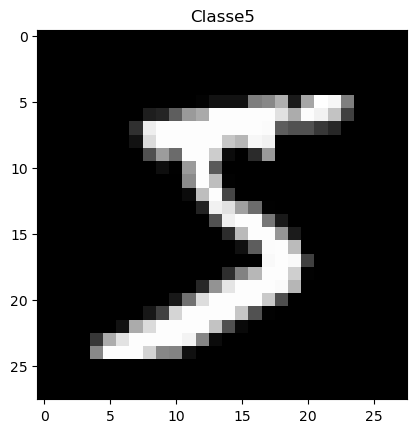

In [10]:
plt.imshow(X_train[0], cmap = 'gray') #pegando a imagem e pintando de cinza
plt.title('Classe' + str(y_train[0])) #botando titulo

Text(0.5, 1.0, 'Classe2')

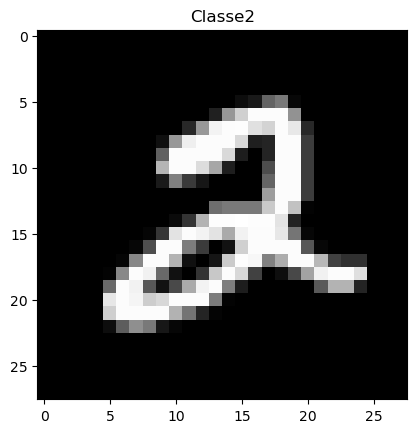

In [11]:
plt.imshow(X_train[5], cmap = 'gray') 
plt.title('Classe' + str(y_train[5])) #mesma coisa

In [19]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1) #dando um reshape no X_train

In [20]:
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1) #dando um reshape no X_test

In [13]:
X_train.shape #vendo o shape

(60000, 28, 28, 1)

In [14]:
X_train = X_train.astype('float32') 
X_test = X_test.astype('float32') #colocando em float32 

In [18]:
X_train /= 255
X_test /= 255 #dividindo os dados pra normalizar

In [21]:
X_train.shape, X_test.shape #vendo o shape novo

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [23]:
X_train.max(), X_test.max() #maximos de cada X

(np.float32(1.5378702e-05), np.float32(1.0))

In [24]:
y_train #vendo os dados

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [25]:
y_train = np_utils.to_categorical(y_train, 10)
y_test = np_utils.to_categorical(y_test, 10) #colocando os dados categoricos pra numericos fazendo o one hot encode

In [26]:
y_train #vendo a variavel

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [27]:
y_train[0] #pegando um dado especifico

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [28]:
y_train[1] #pegando um dado especifico

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [29]:
y_train[2] #pegando um dado especifico

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [31]:
rede_neural = Sequential() #define como sequencial
rede_neural.add(InputLayer(shape = (28, 28, 1))) #camada de entrada
rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu')) #convolucao
rede_neural.add(MaxPooling2D(pool_size = (2, 2))) #reduz a iamgem
rede_neural.add(Flatten()) #passa pra um vetor
rede_neural.add(Dense(units = 128, activation = 'relu')) #funcao relu de ativacao
rede_neural.add(Dense(units = 10, activation = 'softmax')) #funca softmax pra saida

In [32]:
rede_neural.summary() #vendo ela

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy']) #compilando

In [34]:
rede_neural.fit(X_train, y_train, batch_size = 128, epochs = 5, validation_data = (X_test, y_test)) #treinando

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1118 - loss: 2.3016 - val_accuracy: 0.1293 - val_loss: 2.3334
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1275 - val_loss: 2.3413
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1252 - val_loss: 2.3362
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1110 - val_loss: 2.3346
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1124 - loss: 2.3013 - val_accuracy: 0.1166 - val_loss: 2.3358


In [35]:
resultado = rede_neural.evaluate(X_test, y_test) #testando

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1166 - loss: 2.3358


In [37]:
resultado #printa o resultado da rede

[2.3358137607574463, 0.11659999936819077]

In [38]:
rede_neural = Sequential() #define a rede como sequencial
rede_neural.add(InputLayer(shape = (28, 28, 1))) #camada de input

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu')) #adiciona uma camada de convolucao
rede_neural.add(BatchNormalization()) #normaliza os dados
rede_neural.add(MaxPooling2D(pool_size = (2, 2))) #reduz a dimensao

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu')) #mais uma camada de convolucao
rede_neural.add(BatchNormalization()) #normaliza pra passar pra proxima camada
rede_neural.add(MaxPooling2D(pool_size = (2, 2))) #reud denovo

rede_neural.add(Flatten()) #passando pra vetor

rede_neural.add(Dense(units = 128, activation = 'relu')) #define a camada densa com a funcao relu de ativacao
rede_neural.add(Dropout(0.2)) #20% dos neuronios sao desativados 
rede_neural.add(Dense(units = 128, activation = 'relu')) #mais uma camada densa
rede_neural.add(Dropout(0.2)) #mais um dropout de 20%
rede_neural.add(Dense(units = 10, activation = 'softmax')) #funcao de saida como a softmax  

In [39]:
rede_neural.summary() #vendo ela

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [40]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy']) #compilando

In [41]:
rede_neural.fit(X_train, y_train, batch_size = 128, epochs = 5, validation_data = (X_test, y_test)) #treinando

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7626 - loss: 0.7180 - val_accuracy: 0.7934 - val_loss: 1670.3832
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9449 - loss: 0.1807 - val_accuracy: 0.7862 - val_loss: 17663.3945
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9623 - loss: 0.1255 - val_accuracy: 0.7888 - val_loss: 17813.0215
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9687 - loss: 0.1036 - val_accuracy: 0.8261 - val_loss: 13787.7822
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9733 - loss: 0.0850 - val_accuracy: 0.8159 - val_loss: 16775.5957


In [42]:
resultado = rede_neural.evaluate(X_test, y_test) #testando

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8159 - loss: 16775.5996


In [43]:
resultado #vendo os resultados de perda e acuracia

[16775.599609375, 0.8159000277519226]